Syntheitc Data to construct

1. Start with date × geo × leads data

2. For each geo:
   pretend this geo is the test geo

3. Use all other geos as possible controls

4. Look only at the pre-test period

5. Build a synthetic control:
   find a weighted combination of other geos that best matches the test geo historically

6. Measure how good the match is:
   actual test geo - synthetic control

7. Store the error:
   lower error = better test candidate

8. Simulate an experiment:
   add a fake lift, e.g. +5%, to the test geo

9. Ask:
   if a real 5% lift existed, would my method detect it?

10. Repeat many times:
   this gives power

11. Repeat for:
   all geos
   different effect sizes
   different experiment durations

12. Rank geos by:
   good historical fit
   high volume
   enough power in reasonable time

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

dates = pd.date_range("2026-01-01", periods=180)
geos = ["London", "Manchester", "Birmingham", "Leeds", "Glasgow"]

data = []

for geo in geos:
    base = np.random.uniform(500, 1200)

    for i, date in enumerate(dates):
        trend = i * np.random.uniform(0.5, 1.5)
        noise = np.random.normal(0, 50)

        value = base + trend + noise

        data.append([date, geo, value])

df = pd.DataFrame(data, columns=["date", "geo", "leads"])

Get 6 Months of data
Calculate model fit for 4 months and test in 2 months


In [86]:
from sklearn.linear_model import Ridge
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class GeoSelector:
    def __init__(self,df:pd.DataFrame,metric,geo_column):
        self.df = df
        self.metric = metric
        self.geo_column = geo_column
        self.geos = df[self.geo_column].unique().tolist()
        self.results = {}
    
    def divide_data(self,test_geo):
        pivot = self.df.pivot(index="date", columns=self.geo_column, values=self.metric)
        y = pivot[test_geo]
        X = pivot.drop(columns=[test_geo])
        pre_period_x = X.iloc[X.shape[0]-180:X.shape[0]-60]
        post_period_x = X.iloc[X.shape[0]-60:X.shape[0]]
        pre_period_y = y.iloc[y.shape[0]-180:y.shape[0]-60]
        post_period_y = y.iloc[y.shape[0]-60:y.shape[0]]
        return (pre_period_x,post_period_x,pre_period_y,post_period_y)

    def model(self,test_geo):
        pre_period_x,post_period_x,pre_period_y,post_period_y = self.divide_data(test_geo)
        model = Ridge(alpha=1.0)
        model.fit(pre_period_x, pre_period_y)
        y_pred_pre = model.predict(pre_period_x)
        y_pred_post = model.predict(post_period_x)
        return (y_pred_pre,pre_period_y,y_pred_post,post_period_y)

    def error_estimation(self,test_geo):
        y_pred_pre,pre_period_y,y_pred_post,post_period_y = self.model(test_geo)
        rmse_pre = np.sqrt(np.mean((pre_period_y - y_pred_pre) ** 2))
        rmse_post = np.sqrt(np.mean((post_period_y - y_pred_post) ** 2))
        nrmse_pre = rmse_pre / pre_period_y.mean()
        nrmse_post = rmse_post / post_period_y.mean()
        return (nrmse_pre,nrmse_post)
    
    def calculate_all_results(self):
        """Calculate error metrics for all geographies"""
        for test_geo in self.geos:
            nrmse_pre, nrmse_post = self.error_estimation(test_geo)
            self.results[test_geo] = {
                'nrmse_pre': nrmse_pre,
                'nrmse_post': nrmse_post
            }
        return pd.DataFrame.from_dict(self.results, orient='index')

In [ ]:
# Test the simple GeoTest class
geo_test = GeoTest(df, metric='leads', geo_column='geo')

# Test with London
test_geo = 'London'

print(f"Testing {test_geo}...")

# 1. Calculate power (days needed for 80% power with 10% effect)
days_needed = geo_test.calculate_power(test_geo, effect_size=0.10)
print(f"Days needed for 80% power (10% effect): {days_needed}")

# 2. Plot results
print(f"Generating plot for {test_geo}...")
results = geo_test.plot_results(test_geo)
print(f"Lift: {results['lift']:.2f} ({results['lift_percentage']:.2f}%)")

            nrmse_pre  nrmse_post
London       0.063014    0.093408
Manchester   0.045508    0.071836
Birmingham   0.100788    0.110388
Leeds        0.068587    0.091863
Glasgow      0.044816    0.056209


In [87]:
from sklearn.linear_model import Ridge
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

class GeoTest:
    def __init__(self,df:pd.DataFrame,metric,geo_column,geo):
        self.df = df
        self.geo = geo
        self.metric = metric
        self.geo_column = geo_column
    
    def divide_data(self,geo):
        pivot = self.df.pivot(index="date", columns=self.geo_column, values=self.metric)
        y = pivot[geo]
        X = pivot.drop(columns=[geo])
        pre_period_x = X.iloc[X.shape[0]-180:X.shape[0]-60]
        post_period_x = X.iloc[X.shape[0]-60:X.shape[0]]
        pre_period_y = y.iloc[y.shape[0]-180:y.shape[0]-60]
        post_period_y = y.iloc[y.shape[0]-60:y.shape[0]]
        return (pre_period_x,post_period_x,pre_period_y,post_period_y)

    def model(self,geo):
        pre_period_x,post_period_x,pre_period_y,post_period_y = self.divide_data(geo)
        model = Ridge(alpha=1.0)
        model.fit(pre_period_x, pre_period_y)
        y_pred_pre = model.predict(pre_period_x)
        y_pred_post = model.predict(post_period_x)
        return (y_pred_pre,pre_period_y,y_pred_post,post_period_y)

    def error_estimation(self,geo):
        y_pred_pre,pre_period_y,y_pred_post,post_period_y = self.model(geo)
        rmse_pre = np.sqrt(np.mean((pre_period_y - y_pred_pre) ** 2))
        rmse_post = np.sqrt(np.mean((post_period_y - y_pred_post) ** 2))
        nrmse_pre = rmse_pre / pre_period_y.mean()
        nrmse_post = rmse_post / post_period_y.mean()
        return (nrmse_pre,nrmse_post)
    
    def calculate_power(self, effect_sizes=[0.05, 0.10, 0.15, 0.20], power_levels=[0.80, 0.90], max_days=60):
        """
        Calculate days needed for different effect sizes and power levels
        
        Returns: DataFrame with effect_size, power_level, days_needed
        """
        pre_period_x, post_period_x, pre_period_y, post_period_y = self.divide_data(self.geo)
        
        # Train model
        model = Ridge(alpha=1.0)
        model.fit(pre_period_x, pre_period_y)
        y_pred_post = model.predict(post_period_x)
        
        # Calculate baseline variance
        variance = np.var(post_period_y - y_pred_post)
        mean_val = np.mean(post_period_y)
        
        results = []
        
        for effect_size in effect_sizes:
            for power_level in power_levels:
                # Z-scores for different power levels
                z_scores = {0.80: 2.8, 0.90: 3.3, 0.95: 3.9}
                z_score = z_scores.get(power_level, 2.8)
                
                # Calculate days needed
                days_needed = int((z_score * np.sqrt(variance) / (effect_size * mean_val))**2)
                days_needed = min(days_needed, max_days)
                
                results.append({
                    'effect_size': effect_size,
                    'power_level': power_level,
                    'days_needed': days_needed
                })
        
        return pd.DataFrame(results)
    
    def simulate_effect(self, effect_size=0.10, show_plot=True):
        """
        Simulate an effect in the post period and test if mean analysis detects it
        
        Parameters:
        - effect_size: The effect size to simulate (e.g., 0.10 for 10% increase)
        - show_plot: Whether to display the plot
        
        Returns: Dictionary with detection results
        """
        # Get original data
        y_pred_pre, pre_period_y, y_pred_post, post_period_y = self.model(self.geo)
        
        # Calculate original lift (before adding effect)
        original_lift = post_period_y - y_pred_post
        original_mean_lift = np.mean(original_lift)
        
        # Simulate effect: add effect_size to post period
        simulated_post = post_period_y * (1 + effect_size)
        
        # Calculate new lift (after adding effect)
        new_lift = simulated_post - y_pred_post
        new_mean_lift = np.mean(new_lift)
        
        # The actual effect lift is the difference between new and original lifts
        actual_effect_lift = new_mean_lift - original_mean_lift
        expected_effect_lift = effect_size * np.mean(post_period_y)
        
        # Statistical test - t-test on the new lift
        n = len(new_lift)
        std_error = np.std(new_lift) / np.sqrt(n)
        t_stat = new_mean_lift / std_error
        p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n - 1))
        
        # Determine if effect is detected
        detected = p_value < 0.05
        
        if show_plot:
            dates = self.df['date'].unique()[-180:]
            pre_dates = dates[:-60]
            post_dates = dates[-60:]
            
            plt.figure(figsize=(12, 6))
            
            # Plot original data
            plt.plot(pre_dates, pre_period_y, 'b-', label='Actual (Pre)', linewidth=2)
            plt.plot(pre_dates, y_pred_pre, 'b--', label='Synthetic (Pre)', linewidth=2)
            plt.plot(post_dates, post_period_y, 'r-', label='Actual (Post - Original)', linewidth=2, alpha=0.5)
            plt.plot(post_dates, y_pred_post, 'r--', label='Synthetic (Post)', linewidth=2)
            
            # Plot simulated effect
            plt.plot(post_dates, simulated_post, 'g-', label=f'Actual (Post + {effect_size*100:.0f}% Effect)', linewidth=3)
            
            plt.axvline(x=post_dates[0], color='gray', linestyle=':', label='Treatment Start')
            plt.title(f'Effect Simulation - {self.geo} ({effect_size*100:.0f}% Effect)')
            plt.ylabel(self.metric.capitalize())
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        
        return {
            'effect_size': effect_size,
            'original_mean_lift': original_mean_lift,
            'new_mean_lift': new_mean_lift,
            'actual_effect_lift': actual_effect_lift,
            'expected_effect_lift': expected_effect_lift,
            'lift_percentage': (actual_effect_lift / np.mean(y_pred_post)) * 100,
            't_statistic': t_stat,
            'p_value': p_value,
            'detected': detected,
            'std_error': std_error
        }
    
    def plot_results(self):
        """Simple plot of synthetic control results"""
        y_pred_pre, pre_period_y, y_pred_post, post_period_y = self.model(self.geo)
        
        dates = self.df['date'].unique()[-180:]
        pre_dates = dates[:-60]
        post_dates = dates[-60:]
        
        plt.figure(figsize=(12, 6))
        plt.plot(pre_dates, pre_period_y, 'b-', label='Actual (Pre)', linewidth=2)
        plt.plot(pre_dates, y_pred_pre, 'b--', label='Synthetic (Pre)', linewidth=2)
        plt.plot(post_dates, post_period_y, 'r-', label='Actual (Post)', linewidth=2)
        plt.plot(post_dates, y_pred_post, 'r--', label='Synthetic (Post)', linewidth=2)
        
        plt.axvline(x=post_dates[0], color='gray', linestyle=':', label='Treatment Start')
        plt.title(f'Synthetic Control - {self.geo}')
        plt.ylabel(self.metric.capitalize())
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Calculate lift
        lift = np.mean(post_period_y - y_pred_post)
        lift_pct = (lift / np.mean(y_pred_post)) * 100
        
        return {'lift': lift, 'lift_percentage': lift_pct}

Simulating 10% effect...


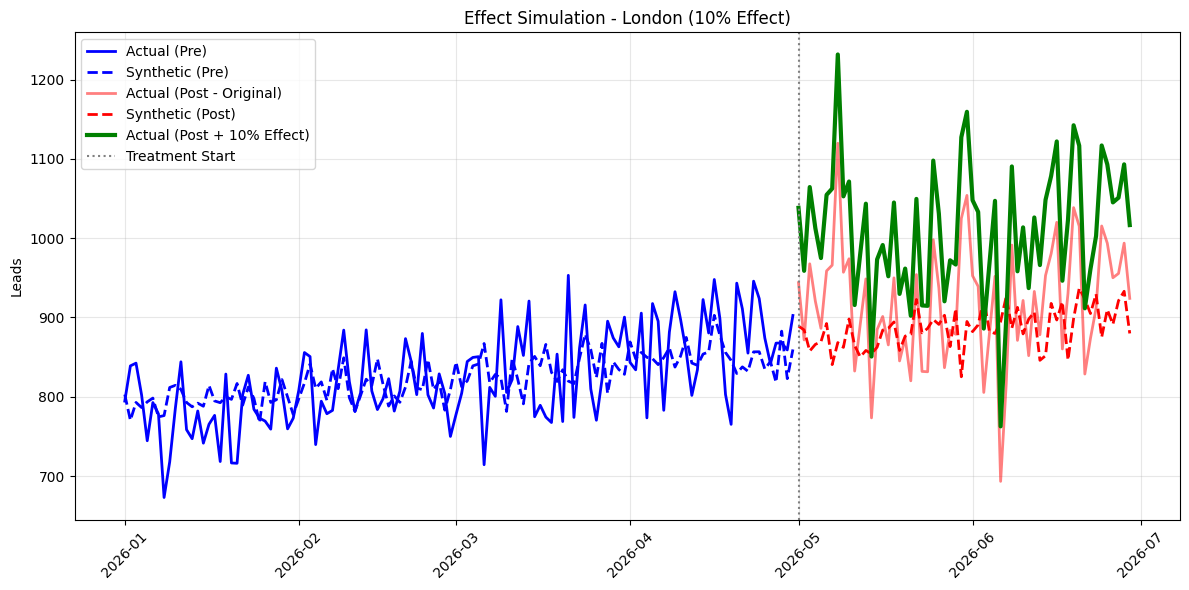

Effect detected: True
P-value: 0.0000
Original lift (before effect): 31.58
New lift (after effect): 123.43
Actual effect lift: 91.86
Expected effect lift: 91.86
Lift percentage: 10.36%

Simulating 5% effect...


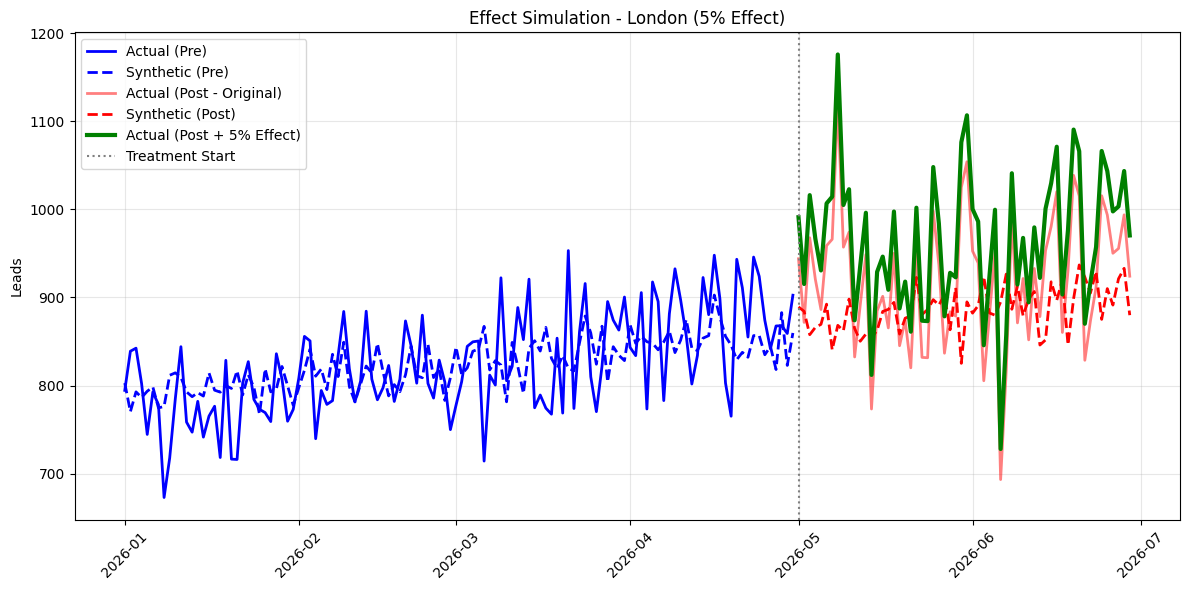

Effect detected: True
P-value: 0.0000
Actual effect lift: 45.93
Expected effect lift: 45.93
Lift percentage: 5.18%


In [88]:
# Test the corrected simulate_effect method
geo_test = GeoTest(df, metric='leads', geo_column='geo', geo='London')

# Simulate a 10% effect
print("Simulating 10% effect...")
result_10 = geo_test.simulate_effect(effect_size=0.10)
print(f"Effect detected: {result_10['detected']}")
print(f"P-value: {result_10['p_value']:.4f}")
print(f"Original lift (before effect): {result_10['original_mean_lift']:.2f}")
print(f"New lift (after effect): {result_10['new_mean_lift']:.2f}")
print(f"Actual effect lift: {result_10['actual_effect_lift']:.2f}")
print(f"Expected effect lift: {result_10['expected_effect_lift']:.2f}")
print(f"Lift percentage: {result_10['lift_percentage']:.2f}%")

# Simulate a 5% effect
print("\nSimulating 5% effect...")
result_5 = geo_test.simulate_effect(effect_size=0.05)
print(f"Effect detected: {result_5['detected']}")
print(f"P-value: {result_5['p_value']:.4f}")
print(f"Actual effect lift: {result_5['actual_effect_lift']:.2f}")
print(f"Expected effect lift: {result_5['expected_effect_lift']:.2f}")
print(f"Lift percentage: {result_5['lift_percentage']:.2f}%")

In [94]:
# Power Analysis for All Geographies using Original Method
geos = df['geo'].unique()
effect_sizes = [0.05, 0.10, 0.15, 0.20]
power_levels = [0.80, 0.90]

print("Power Analysis Results")
print("=" * 50)

all_results = []

for geo in geos:
    print(f"\nAnalyzing {geo}...")
    
    # Use original GeoTest class
    geo_test = GeoTest(df, metric='leads', geo_column='geo', geo=geo)
    power_results = geo_test.calculate_power(effect_sizes=effect_sizes, power_levels=power_levels)
    
    print(f"{'Effect Size':<12} {'80% Power':<10} {'90% Power':<10}")
    print("-" * 35)
    
    for _, row in power_results.iterrows():
        effect_pct = f"{row['effect_size']*100:.0f}%"
        days_80 = row['days_needed'] if row['power_level'] == 0.80 else ""
        days_90 = row['days_needed'] if row['power_level'] == 0.90 else ""
        
        if days_80:
            print(f"{effect_pct:<12} {days_80:<10} ", end="")
            # Find 90% power result
            row_90 = power_results[(power_results['effect_size'] == row['effect_size']) & 
                                  (power_results['power_level'] == 0.90)]
            if len(row_90) > 0:
                print(f"{row_90.iloc[0]['days_needed']:<10}")
            else:
                print(f"{'N/A':<10}")
        
        # Store results
        all_results.append({
            'geo': geo,
            'effect_size': row['effect_size'],
            'power_level': row['power_level'],
            'days_needed': row['days_needed']
        })

# Create summary DataFrame
results_df = pd.DataFrame(all_results)

print("\n" + "=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)

# Average days needed by effect size and power level
summary = results_df.groupby(['effect_size', 'power_level'])['days_needed'].mean().unstack()
print("Average Days Needed:")
print(summary.round(1))

# Find geos with lowest/highest requirements
for effect_size in effect_sizes:
    for power_level in power_levels:
        subset = results_df[(results_df['effect_size'] == effect_size) & 
                          (results_df['power_level'] == power_level)]
        
        best_geo = subset.loc[subset['days_needed'].idxmin(), 'geo']
        worst_geo = subset.loc[subset['days_needed'].idxmax(), 'geo']
        
        print(f"\n{effect_size*100:.0f}% effect at {power_level*100:.0f}% power:")
        print(f"  Best geo: {best_geo} ({subset['days_needed'].min()} days)")
        print(f"  Worst geo: {worst_geo} ({subset['days_needed'].max()} days)")

Power Analysis Results

Analyzing London...
Effect Size  80% Power  90% Power 
-----------------------------------
5%           23.0       32.0      
10%          5.0        8.0       
15%          2.0        3.0       
20%          1.0        2.0       

Analyzing Manchester...
Effect Size  80% Power  90% Power 
-----------------------------------
5%           10.0       14.0      
10%          2.0        3.0       
15%          1.0        1.0       

Analyzing Birmingham...
Effect Size  80% Power  90% Power 
-----------------------------------
5%           32.0       44.0      
10%          8.0        11.0      
15%          3.0        4.0       
20%          2.0        2.0       

Analyzing Leeds...
Effect Size  80% Power  90% Power 
-----------------------------------
5%           23.0       33.0      
10%          5.0        8.0       
15%          2.0        3.0       
20%          1.0        2.0       

Analyzing Glasgow...
Effect Size  80% Power  90% Power 
--------------------